<a href="https://colab.research.google.com/github/zubaeteee20210205109-droid/Trial/blob/main/Attention_Enhanced_Hybrid_CNN_EfficientNetB3_Model_for_Automated_Arsenic_Skin_Disease_Classification(problem_4_class_created).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
import shutil
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

In [17]:
original_path = "/content/drive/MyDrive/ArsenicSkinImageBD/Original"

base_split_path = "/content/drive/MyDrive/ArsenicSplit"

train_path = os.path.join(base_split_path, "train")
test_path  = os.path.join(base_split_path, "test")

classes = ["infacted", "not_infacted"]

In [18]:
for folder in [train_path, test_path]:
    for cls in classes:
        os.makedirs(os.path.join(folder, cls), exist_ok=True)

In [19]:
split_ratio = 0.8
random.seed(42)

for cls in classes:
    img_list = os.listdir(os.path.join(original_path, cls))
    random.shuffle(img_list)

    split_index = int(len(img_list) * split_ratio)

    train_imgs = img_list[:split_index]
    test_imgs = img_list[split_index:]

    # TRAIN COPY
    for img in train_imgs:
        src = os.path.join(original_path, cls, img)
        dst = os.path.join(train_path, cls, img)
        shutil.copy(src, dst)

    # TEST COPY
    for img in test_imgs:
        src = os.path.join(original_path, cls, img)
        dst = os.path.join(test_path, cls, img)
        shutil.copy(src, dst)

In [20]:
IMG_SIZE = 300
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [21]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 1029 images belonging to 4 classes.
Found 259 images belonging to 4 classes.


In [22]:
input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

base_model = EfficientNetB3(
    weights='imagenet',
    include_top=False,
    input_tensor=input_layer
)

for layer in base_model.layers[:-30]:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model.output)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

output = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(input_layer, output)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
callbacks = [
    EarlyStopping(patience=6, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.3),
    ModelCheckpoint("best_model.h5", save_best_only=True)
]


In [25]:
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.3221 - loss: 1.9733 

33/33 ━━━━━━━━━━━━━━━━━━━━ 688s 20s/step - accuracy: 0.3751 - loss: 1.7445 - val_accuracy: 0.4054 - val_loss: 1.3214 - learning_rate: 1.0000e-04
Epoch 2/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.5425 - loss: 1.2911 

33/33 ━━━━━━━━━━━━━━━━━━━━ 626s 19s/step - accuracy: 0.5773 - loss: 1.2116 - val_accuracy: 0.6139 - val_loss: 1.1405 - learning_rate: 1.0000e-04
Epoch 3/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.6512 - loss: 1.0290 

33/33 ━━━━━━━━━━━━━━━━━━━━ 601s 18s/step - accuracy: 0.6958 - loss: 0.9219 - val_accuracy: 0.6988 - val_loss: 0.9954 - learning_rate: 1.0000e-04
Epoch 4/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.7404 - loss: 0.7426 

33/33 ━━━━━━━━━━━━━━━━━━━━ 580s 18s/step - accuracy: 0.7648 - loss: 0.6966 - val_accuracy: 0.7683 - val_loss: 0.8334 - learning_rate: 1.0000e-04
Epoch 5/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8231 - loss: 0.5166 

...

33/33 ━━━━━━━━━━━━━━━━━━━━ 572s 17s/step - accuracy: 0.9436 - loss: 0.1957 - val_accuracy: 0.9189 - val_loss: 0.2569 - learning_rate: 1.0000e-04
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9375 - loss: 0.2268 

33/33 ━━━━━━━━━━━━━━━━━━━━ 570s 17s/step - accuracy: 0.9436 - loss: 0.2048 - val_accuracy: 0.9305 - val_loss: 0.2323 - learning_rate: 1.0000e-04
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9566 - loss: 0.1628 

33/33 ━━━━━━━━━━━━━━━━━━━━ 585s 18s/step - accuracy: 0.9572 - loss: 0.1651 - val_accuracy: 0.9498 - val_loss: 0.1607 - learning_rate: 1.0000e-04
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.9574 - loss: 0.1581 

33/33 ━━━━━━━━━━━━━━━━━━━━ 588s 18s/step - accuracy: 0.9563 - loss: 0.1643 - val_accuracy: 0.9575 - val_loss: 0.1518 - learning_rate: 1.0000e-04
Epoch 16/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 624s 19s/step - accuracy: 0.9582 - loss: 0.1549 - val_accuracy: 0.9498 - val_loss: 0.1686 - learning_rate: 1.0000e-04
Epoch 17/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.9742 - loss: 0.1345 

33/33 ━━━━━━━━━━━━━━━━━━━━ 577s 17s/step - accuracy: 0.9650 - loss: 0.1750 - val_accuracy: 0.9537 - val_loss: 0.1517 - learning_rate: 1.0000e-04
Epoch 18/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 621s 18s/step - accuracy: 0.9640 - loss: 0.1257 - val_accuracy: 0.9537 - val_loss: 0.1574 - learning_rate: 1.0000e-04
Epoch 19/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 573s 17s/step - accuracy: 0.9728 - loss: 0.1146 - val_accuracy: 0.9537 - val_loss: 0.1677 - learning_rate: 1.0000e-04
Epoch 20/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 617s 19s/step - accuracy: 0.9611 - loss: 0.1409 - val_accuracy: 0.9537 - val_loss: 0.1522 - learning_rate: 1.0000e-04


In [26]:
loss, acc = model.evaluate(test_generator)

print("="*40)
print("Accuracy: {:.2f}%".format(acc * 100))
print("="*40)

9/9 ━━━━━━━━━━━━━━━━━━━━ 95s 10s/step - accuracy: 0.9537 - loss: 0.1517
Accuracy: 95.37%


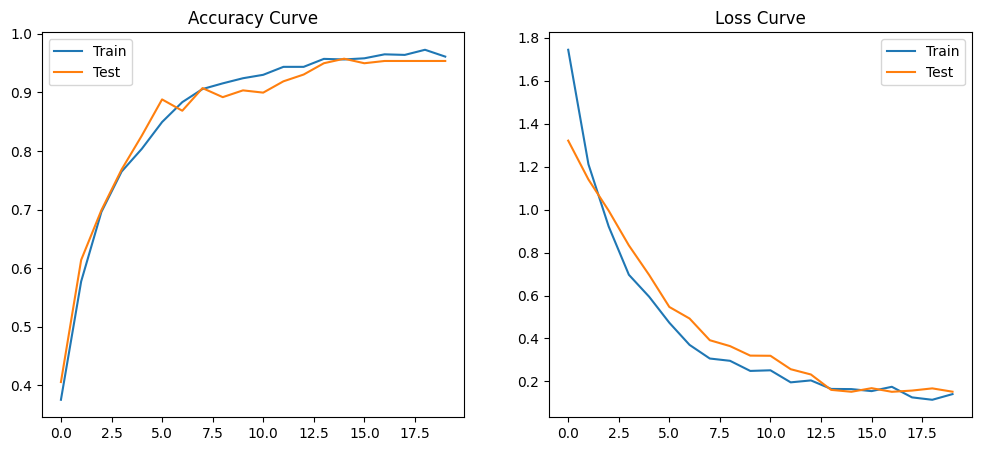

In [27]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy Curve")
plt.legend(['Train','Test'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.legend(['Train','Test'])

plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 120s 11s/step


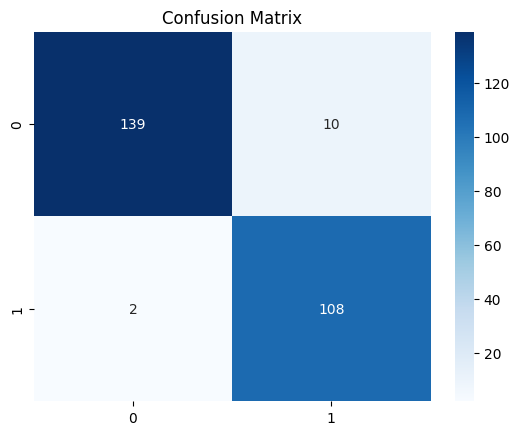

In [28]:
test_generator.reset()
pred = model.predict(test_generator)

y_pred = np.argmax(pred, axis=1)
y_true = test_generator.classes

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [29]:
print(classification_report(
    y_true,
    y_pred,
    target_names=list(test_generator.class_indices.keys())
))

ValueError: Number of classes, 2, does not match size of target_names, 4. Try specifying the labels parameter

In [30]:
print(test_generator.class_indices)

{'infacted': 0, 'infected': 1, 'not_infacted': 2, 'not_infected': 3}


In [31]:
import os

base = "/content/drive/MyDrive/ArsenicSkinImageBD/Original"

for folder in os.listdir(base):
    path = os.path.join(base, folder)

    if os.path.isdir(path):
        print(folder, len(os.listdir(path)))

not_infacted 546
infacted 742


In [32]:
import os

print("TRAIN:")
print(os.listdir("/content/drive/MyDrive/ArsenicSplit/train"))

print("\nTEST:")
print(os.listdir("/content/drive/MyDrive/ArsenicSplit/test"))

TRAIN:
['infected', 'not_infected', 'infacted', 'not_infacted']

TEST:
['infected', 'not_infected', 'infacted', 'not_infacted']


In [33]:
fpr, tpr, _ = roc_curve(y_true, pred[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

ValueError: y_true takes value in {0, 2} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.